<table border=0 width="100%"><tr><td><p align="left"><img src="..\img\logo.png" align="left" width=300></p></td><td><font size=3><B>Data analysis (Python) - Numpy (Jun Wang)</B></font></td></tr></table>

where are we now?

we can conduct **data preprocessing** with numpy and pandas


<img src="../img/python_analysis.png" align='left' height="50" width="500"/>



# Content
* array and its attributes
* array slicing
* computation on arrays
* mnist

# array and its attributes

## create array

In [1]:
L1 = [True, "2", 3.0, 4]  # 先来看一看列表
types = [type(i) for i in L1]

In [2]:
types

[bool, str, float, int]

在实现层面，**数组本质上包含一个指向一个连续数据块的指针。**
然而，**Python列表包含一个指向指针块的指针，每个指针又指向一个完整的Python对象。**如下图所示：

<center><img src="../img/array.png" align='left' height="350" width="400"/></center>

[temperature data](https://www.inferentialthinking.com/chapters/05/1/Arrays.html) in data 8, we create arrays of average daily high temperatures for the decades surrounding 1850, 1900, 1950, and 2000. http://data8.org/

In [3]:
# please install datascience before running this cell # data 8 的方法介绍
from datascience import *

In [4]:
baseline_high = 14.48
highs = make_array(baseline_high - 0.881, baseline_high - 0.093,
                   baseline_high + 0.105, baseline_high + 0.684)
highs

array([ 13.599,  14.387,  14.585,  15.164])

In [5]:
type(highs)

numpy.ndarray

In [6]:
import numpy as np # 更加底层的 numpy

In [7]:
# Creating Arrays from Python Lists  一维数组（向量）
a = np.array([4.2,2.2,8.4,6.7])
type(a)

numpy.ndarray

In [8]:
a.dtype # 与 type（a）的区别

dtype('float64')

In [9]:
# it is a scale（0维，标量）

np.array(12).shape
# np.array(12)

()

In [10]:
# it is a vector
a = np.arange(12)
a

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

In [11]:
a.shape

(12,)

In [12]:
b = np.array([[2,3],
              [5,3],
              [8,3]])  # 3乘以3 三行三列 可以改成     ### 3行1列么？
b.shape

(3, 2)

In [13]:
c = np.arange(1,19)
c
# c.shape
# print(c.shape)


array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18])

In [14]:
c = np.arange(1,19).reshape(3,3,2) # 不同维度
c

array([[[ 1,  2],
        [ 3,  4],
        [ 5,  6]],

       [[ 7,  8],
        [ 9, 10],
        [11, 12]],

       [[13, 14],
        [15, 16],
        [17, 18]]])

In [15]:
np.zeros(10,dtype=float) # 全部为 0

array([ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.])

In [16]:
np.zeros((3,5,5),dtype=int) # 添加形状

array([[[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]],

       [[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]],

       [[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]]])

In [17]:
np.ones((3,5),dtype=float) #全部为 1

array([[ 1.,  1.,  1.,  1.,  1.],
       [ 1.,  1.,  1.,  1.,  1.],
       [ 1.,  1.,  1.,  1.,  1.]])

In [18]:
np.full((3,6,5), 3.14) # 所有元素都相同 3.14

array([[[ 3.14,  3.14,  3.14,  3.14,  3.14],
        [ 3.14,  3.14,  3.14,  3.14,  3.14],
        [ 3.14,  3.14,  3.14,  3.14,  3.14],
        [ 3.14,  3.14,  3.14,  3.14,  3.14],
        [ 3.14,  3.14,  3.14,  3.14,  3.14],
        [ 3.14,  3.14,  3.14,  3.14,  3.14]],

       [[ 3.14,  3.14,  3.14,  3.14,  3.14],
        [ 3.14,  3.14,  3.14,  3.14,  3.14],
        [ 3.14,  3.14,  3.14,  3.14,  3.14],
        [ 3.14,  3.14,  3.14,  3.14,  3.14],
        [ 3.14,  3.14,  3.14,  3.14,  3.14],
        [ 3.14,  3.14,  3.14,  3.14,  3.14]],

       [[ 3.14,  3.14,  3.14,  3.14,  3.14],
        [ 3.14,  3.14,  3.14,  3.14,  3.14],
        [ 3.14,  3.14,  3.14,  3.14,  3.14],
        [ 3.14,  3.14,  3.14,  3.14,  3.14],
        [ 3.14,  3.14,  3.14,  3.14,  3.14],
        [ 3.14,  3.14,  3.14,  3.14,  3.14]]])

In [19]:
# Create a 3x3 array of normally distributed random values # 构建随机的数组
# with mean 0 and standard deviation 1 
np.random.normal(0, 1, (5,3))   # 符合标准正态分布 仿真任务中作用很大

array([[-0.67249713, -1.18263103,  0.70821119],
       [ 0.40086207, -1.44853848,  1.07260221],
       [ 0.18399456, -1.20570316,  2.41120943],
       [ 1.14100013, -1.13087524, -0.10591935],
       [ 0.71687836,  0.46356721, -0.70898094]])

In [20]:
np.random.normal?

In [21]:
np.eye(4) # 对角矩阵

array([[ 1.,  0.,  0.,  0.],
       [ 0.,  1.,  0.,  0.],
       [ 0.,  0.,  1.,  0.],
       [ 0.,  0.,  0.,  1.]])

In [22]:
np.random.randint(0, 10, (3, 3)) # 0 到 10 ，但是不包括 10

array([[0, 0, 1],
       [1, 0, 3],
       [6, 3, 3]])

In [23]:
np.random.randint?

 # the columns of titanic.csv

| index | column name |
| ------ | ------ | 
| 0 | Survived | 
| 1 | Pclass | 
| 2 | Name | 
| 3 | Sex | 
| 4 | Age | 
| 5 | Siblings | 
| 6 | Parents | 
| 7 | Fare |  

In [24]:
# read numpy from csv file
import numpy as np
titanic = "titanic.csv"
titanic_data = np.loadtxt(titanic,delimiter=",",skiprows= 1,usecols=(0,1,3,4,7),dtype=str)
# 逗号间隔 skiprows 不要的行 usecols 选择的列
titanic_data 

array([['0', '3', 'male', '22', '7.25'],
       ['1', '1', 'female', '38', '71.2833'],
       ['1', '3', 'female', '26', '7.925'],
       ..., 
       ['0', '3', 'female', '7', '23.45'],
       ['1', '1', 'male', '26', '30'],
       ['0', '3', 'male', '32', '7.75']],
      dtype='<U8')

## NumPy Array Attributes

In [25]:
#长度为小于8位的unicode类型数据-字符串
titanic_data.dtype

dtype('<U8')

In [26]:
titanic_data.shape  # 887 行 ，5 列

(887, 5)

In [27]:
titanic_data.size # 多少个元素

4435

In [28]:
titanic_data.ndim # 几维数组

2

# array slicing

## Array slice operation  切片

In [29]:
# the first row
# titanic_data.ndim
titanic_data[0]

array(['0', '3', 'male', '22', '7.25'],
      dtype='<U8')

In [30]:
# 前10行
titanic_data[:10]

array([['0', '3', 'male', '22', '7.25'],
       ['1', '1', 'female', '38', '71.2833'],
       ['1', '3', 'female', '26', '7.925'],
       ['1', '1', 'female', '35', '53.1'],
       ['0', '3', 'male', '35', '8.05'],
       ['0', '3', 'male', '27', '8.4583'],
       ['0', '1', 'male', '54', '51.8625'],
       ['0', '3', 'male', '2', '21.075'],
       ['1', '3', 'female', '27', '11.1333'],
       ['1', '2', 'female', '14', '30.0708']],
      dtype='<U8')

In [31]:
# 全部行
titanic_data[:]

array([['0', '3', 'male', '22', '7.25'],
       ['1', '1', 'female', '38', '71.2833'],
       ['1', '3', 'female', '26', '7.925'],
       ..., 
       ['0', '3', 'female', '7', '23.45'],
       ['1', '1', 'male', '26', '30'],
       ['0', '3', 'male', '32', '7.75']],
      dtype='<U8')

In [32]:
# the first colum
titanic_data[:,0]

array(['0', '1', '1', '1', '0', '0', '0', '0', '1', '1', '1', '1', '0',
       '0', '0', '1', '0', '1', '0', '1', '0', '1', '1', '1', '0', '1',
       '0', '0', '1', '0', '0', '1', '1', '0', '0', '0', '1', '0', '0',
       '1', '0', '0', '1', '1', '0', '0', '1', '0', '0', '0', '0', '1',
       '1', '0', '1', '1', '0', '1', '0', '0', '1', '0', '0', '0', '1',
       '1', '0', '1', '0', '0', '0', '0', '0', '1', '0', '0', '0', '1',
       '1', '0', '1', '1', '0', '1', '1', '0', '0', '1', '0', '0', '0',
       '0', '0', '0', '0', '0', '1', '1', '0', '0', '0', '0', '0', '0',
       '0', '1', '1', '0', '1', '0', '0', '0', '0', '0', '0', '0', '0',
       '0', '0', '0', '0', '0', '1', '0', '1', '0', '1', '1', '0', '0',
       '0', '0', '1', '0', '0', '1', '0', '0', '0', '0', '1', '1', '0',
       '0', '0', '1', '0', '0', '0', '0', '1', '0', '0', '0', '0', '1',
       '0', '0', '0', '0', '1', '0', '0', '0', '1', '1', '0', '0', '0',
       '0', '0', '1', '0', '0', '0', '0', '0', '0', '0', '0', '0

In [33]:
# 前两列
titanic_data[:,[0,1]]

array([['0', '3'],
       ['1', '1'],
       ['1', '3'],
       ..., 
       ['0', '3'],
       ['1', '1'],
       ['0', '3']],
      dtype='<U8')

In [34]:
# 前两列
titanic_data[:,:2]

array([['0', '3'],
       ['1', '1'],
       ['1', '3'],
       ..., 
       ['0', '3'],
       ['1', '1'],
       ['0', '3']],
      dtype='<U8')

In [35]:
# the first element 最左上角的元素

titanic_data[2][2]

# 使用布尔型的切片

# [True] 

'female'

In [36]:
# the sex column  使用布尔型，作为下标，进行切片

female_bool = (titanic_data[:,2] =="female")
male_bool =  (titanic_data[:,2] =="male")

male_bool

array([ True, False, False, False,  True,  True,  True,  True, False,
       False, False, False,  True,  True, False, False,  True,  True,
       False, False,  True,  True, False,  True, False, False,  True,
        True, False,  True,  True, False, False,  True,  True,  True,
        True,  True, False, False, False, False, False, False,  True,
        True, False,  True, False,  True,  True, False, False,  True,
        True, False,  True, False,  True,  True, False,  True,  True,
        True,  True, False,  True, False,  True,  True, False,  True,
        True,  True,  True,  True,  True,  True, False,  True,  True,
       False,  True, False, False,  True,  True, False,  True,  True,
        True,  True,  True,  True,  True,  True,  True, False,  True,
       False,  True,  True,  True,  True,  True, False,  True,  True,
       False,  True, False,  True, False, False,  True,  True,  True,
        True, False,  True,  True,  True, False,  True,  True,  True,
        True, False,

In [37]:
# the count of men
sum(female_bool)
sum(male_bool)

573

In [38]:
# man and woman

man = titanic_data[male_bool] # 切片的布尔值，对应 ture 的地方，把他拿出来

# titanic_data[:,2] =="male"

woman = titanic_data[female_bool]

man
# woman

# man.shape
# woman.shape

array([['0', '3', 'male', '22', '7.25'],
       ['0', '3', 'male', '35', '8.05'],
       ['0', '3', 'male', '27', '8.4583'],
       ..., 
       ['0', '2', 'male', '27', '13'],
       ['1', '1', 'male', '26', '30'],
       ['0', '3', 'male', '32', '7.75']],
      dtype='<U8')

In [39]:
man_f = man[:,[0,1,3,4]] # remove the sex column, you can also try function np.delete()  # 重新切片，然后赋值给 man_f （去除性别列）
man_f = man_f.astype( "float32" ) # change the data type
man_f

array([[  0.    ,   3.    ,  22.    ,   7.25  ],
       [  0.    ,   3.    ,  35.    ,   8.05  ],
       [  0.    ,   3.    ,  27.    ,   8.4583],
       ..., 
       [  0.    ,   2.    ,  27.    ,  13.    ],
       [  1.    ,   1.    ,  26.    ,  30.    ],
       [  0.    ,   3.    ,  32.    ,   7.75  ]], dtype=float32)

In [40]:
woman_f = woman[:,[0,1,3,4]]
woman_f = woman_f.astype( "float32" )
woman_f.shape

(314, 4)

## no-copy views and concatenation

In [41]:
# Subarrays as no-copy views    数组切片与列表的切片有没有差异呢？？？？？
a = np.arange(6).reshape(2,3)
a

array([[0, 1, 2],
       [3, 4, 5]])

In [42]:
b = a[0:2,0:2]
print(b)

b[0,0] = 1  # 赋值
print(b)

print(a) # 切片发生改变，原来的数组也发生改变

[[0 1]
 [3 4]]
[[1 1]
 [3 4]]
[[1 1 2]
 [3 4 5]]


In [43]:
# copy operation in list
L2 = [1,2,3,4]
Ls = L2[0:2]

print (Ls)
print (L2)

Ls[0] = 100
print (Ls)
print (L2) # L2没有发生变化

[1, 2]
[1, 2, 3, 4]
[100, 2]
[1, 2, 3, 4]


In [44]:
# conversion of a one-dimensional array into a two-dimensional row or column matrix  # 一维数组 变成 二维数组
x = np.array([1, 2, 3])
# row vector via reshape
print(x.reshape(1,3)) # 增加了 行的维度
x

[[1 2 3]]


array([1, 2, 3])

In [45]:
# row vector via newaxis 
print(x[np.newaxis, :])  # 一行三列 # 增加维度
# column vector via newaxis
print(x[:,np.newaxis])  # 三行一列 # 增加维度

[[1 2 3]]
[[1]
 [2]
 [3]]


### numpy中newaxis函数的基本用法及其理解
https://blog.csdn.net/THMAIL/article/details/121762644

In [46]:
# Array Concatenation  一维数组的连接
x = np.array([1, 2, 3])
y = np.array([3, 2, 1])
np.concatenate([x, y])

array([1, 2, 3, 3, 2, 1])

参数axis：第0轴沿着行的方向（行）垂直向下，第1轴沿着列的方向水平（列）延申

<img src="../img/axis.jpg" align='left' height="400" width="500"/>

In [47]:
# Array Concatenation of different dimensions 二维数组的连接，需要引入轴的概念
x = np.arange(6).reshape(2,3)
y = np.arange(6).reshape(2,3)

print(x)
print(y)

# np.concatenate([x, y],axis = 0)
np.concatenate([x, y])
# np.concatenate([x, y],axis = 1)
# https://www.jianshu.com/p/5e764eb1ff9e
# https://zhuanlan.zhihu.com/p/31275071

[[0 1 2]
 [3 4 5]]
[[0 1 2]
 [3 4 5]]


array([[0, 1, 2],
       [3, 4, 5],
       [0, 1, 2],
       [3, 4, 5]])

# computation on arrays

## general operations on arrays

In [48]:
a = np.random.randint(-10,10,(2,3)) # -10-10,2行3列
a

array([[ -4,  -5, -10],
       [ -4,   3,  -3]])

In [49]:
a+1 # 类似广播的形式

array([[-3, -4, -9],
       [-3,  4, -2]])

In [50]:
np.absolute(a) # 绝对值

array([[ 4,  5, 10],
       [ 4,  3,  3]])

<img src="../img/dot.png" align='left' height="300" width="400"/>

In [51]:
# np.dot

a = np.array([2,2,3])
b = np.array([1,2,3])

print(a * b) # 对应元素相乘

print(np.dot(a,b)) # 矩阵相乘

[2 4 9]
15


In [52]:

x = np.array([1,2])
W = np.array([[1,3,5],
             [2,4,6]])

print(x.shape) # 1行2列
print(W.shape) # 2行3列

print(np.dot(x,W)) # 向量和矩阵相乘

(2,)
(2, 3)
[ 5 11 17]


In [53]:
x = np.array([[1,2],
              [1,1]])

W = np.array([[1,3,5],
             [2,4,6]])

print(x.shape) #2行2列
print(W.shape) #2行3列

print(np.dot(x,W)) # 矩阵和矩阵相乘  满足条件：第一个矩阵 列 等于 第二个矩阵的 行

(2, 2)
(2, 3)
[[ 5 11 17]
 [ 3  7 11]]


## compare the mean Survived for man and woman

In [54]:
man_f.shape

(573, 4)

In [55]:
woman_f

array([[  1.    ,   1.    ,  38.    ,  71.2833],
       [  1.    ,   3.    ,  26.    ,   7.925 ],
       [  1.    ,   1.    ,  35.    ,  53.1   ],
       ..., 
       [  0.    ,   3.    ,  39.    ,  29.125 ],
       [  1.    ,   1.    ,  19.    ,  30.    ],
       [  0.    ,   3.    ,   7.    ,  23.45  ]], dtype=float32)

In [56]:
man_f[:,0].mean() # 第一列均值 男性存活均值

0.19022688

In [57]:
woman_f[:,0].mean() # 第一列均值 女性存活均值

0.74203819

# mnist


The MNIST database of handwritten digits, available from this page, has a training set of 60,000 examples, and a test set of 10,000 examples. It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image.

[THE MNIST DATABASE of handwritten digits](http://yann.lecun.com/exdb/mnist/index.html)

The MNIST dataset is used by researchers to test and compare their research results with others. The lowest error rates in literature are as low as 0.21 percent.

In [58]:
import scipy.io as sio
mnist = sio.loadmat("mnist-original.mat")

### python读取不同类型的文件
https://blog.csdn.net/weixin_45698190/article/details/115320351
https://www.py.cn/jishu/jichu/30207.html

In [59]:
mnist

{'__header__': b'MATLAB 5.0 MAT-file Platform: posix, Created on: Sun Mar 30 03:19:02 2014',
 '__version__': '1.0',
 '__globals__': [],
 'mldata_descr_ordering': array([[array(['label'],
       dtype='<U5'),
         array(['data'],
       dtype='<U4')]], dtype=object),
 'data': array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ..., 
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], dtype=uint8),
 'label': array([[ 0.,  0.,  0., ...,  9.,  9.,  9.]])}

In [60]:
mnist.get("data").shape  # 由于存储格式的原因，70000是图片数量，784

(784, 70000)

In [61]:
data = mnist.get("data").T
label = mnist.get("label").T

In [62]:
data.shape  # 28 乘以 28 = 784

(70000, 784)

In [63]:
label.shape # 打标签


(70000, 1)

In [64]:
label[:]

array([[ 0.],
       [ 0.],
       [ 0.],
       ..., 
       [ 9.],
       [ 9.],
       [ 9.]])

In [65]:
index = np.arange(10)
index = np.random.permutation(index)  # 数据打乱的方法，索引打乱
index

array([0, 6, 9, 1, 7, 8, 4, 5, 3, 2])

In [66]:
permutation = np.random.permutation(data.shape[0]) # 按照数据的行，进行打乱

shuffled_data = data[permutation,:] # 重新索引

shuffled_label = label[permutation] # 重新索引

In [67]:
shuffled_label[:10]

array([[ 7.],
       [ 8.],
       [ 5.],
       [ 4.],
       [ 3.],
       [ 4.],
       [ 6.],
       [ 9.],
       [ 0.],
       [ 6.]])

In [68]:
shuffled_data[10]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,  36, 125, 154, 254, 255, 254, 254,
       174, 115,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0, 204, 249, 253, 253, 253, 253,
       253, 253, 253, 253, 241,  54,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0, 118, 142, 14

In [69]:
# normalize the data  标准化方法：除以最大值,机器学习训练更加稳定
data = data/255.0

In [70]:
import matplotlib.pyplot as plt # 可视化  # jupyter中显示图片
%matplotlib inline 

shuffled_data[333]
# shuffled_data[2456].shape
# shuffled_data[2456].reshape(28,28)

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0, 102, 242, 140,   0,   0,   0,   

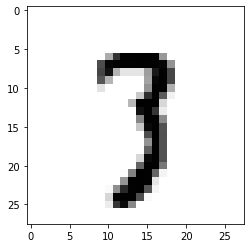

In [71]:
digit = shuffled_data[69998].reshape(28,28)
plt.imshow(digit,cmap=plt.cm.binary) # 黑白图片展示
plt.show()

In [72]:
shuffled_label[69998]

array([ 3.])

In [73]:
plt.imshow?

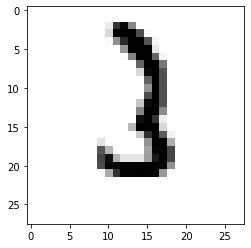

In [74]:
# 图片左右翻转

digit = digit[::-1,:]
plt.imshow(digit,cmap=plt.cm.binary)
plt.show()

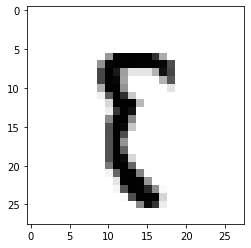

In [75]:
# 图片上下翻转

digit = digit[::-1,::-1]
plt.imshow(digit,cmap=plt.cm.binary)
plt.show()

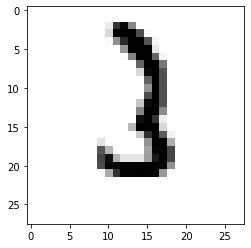

In [76]:
digit = digit[::-1,::-1]
plt.imshow(digit,cmap=plt.cm.binary)
plt.show()

**Thank you for your attention**